# Lab 03 - Rút trích dữ liệu và tiền xử lý: Pima Indians Diabetes

Notebook này tổng hợp và chuẩn hóa các phân tích rời rạc từ các thư mục thành viên (`chibang`, `duybao`, `tranhuyvu`, `truongphat`) thành một notebook thống nhất theo hướng trình bày báo cáo thực hành hoàn chỉnh.

## Bối cảnh bài toán
Pima Indians Diabetes là bài toán phân lớp nhị phân nhằm dự đoán khả năng mắc bệnh tiểu đường (`outcome=1`) từ các chỉ số y sinh. Dữ liệu có đặc trưng định lượng nhưng tồn tại vấn đề chất lượng dữ liệu (đặc biệt là giá trị `0` phi sinh lý trong một số biến), vì vậy bước rút trích và tiền xử lý đóng vai trò then chốt.

## Mục tiêu nghiên cứu
- Thực hiện đầy đủ quy trình lab: định nghĩa vấn đề, chuẩn bị dữ liệu, phân tích dữ liệu, tiền xử lý, chia tập thực nghiệm.
- So sánh nhiều phương án tiền xử lý (Median, KNN, Iterative/MICE) và chuẩn hóa (Standard, MinMax).
- Đánh giá baseline model (Logistic Regression, Random Forest) để chọn cấu hình preprocessing hợp lý.

## Câu hỏi kiểm chứng
1. Chính sách `zero-as-missing` có cải thiện tính nhất quán thống kê và mô hình không?
2. Với dữ liệu Pima, chiến lược imputation/scaling nào cho kết quả ổn định hơn trên tập validation/test?
3. Trade-off giữa `precision` và `recall` thay đổi ra sao giữa các mô hình baseline?

## Phạm vi và giả định
- Chỉ sử dụng dữ liệu tại `Lab_03/data/pima-indians-diabetes.csv` và mô tả từ `Lab_03/data/pima-indians-diabetes.names`.
- Không mở rộng thêm nguồn dữ liệu ngoài hoặc thông tin lâm sàng bổ sung.
- Kết quả tập trung vào so sánh quy trình tiền xử lý và baseline, chưa tối ưu hyperparameter chuyên sâu.

> Notebook thuần Jupyter, không dùng marimo syntax (`mo.*`, `@app.cell`, `app.run`).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

plt.style.use("default")
sns.set_theme(style="whitegrid")

In [2]:
column_names = [
    'pregnancies',
    'glucose',
    'blood_pressure',
    'skin_thickness',
    'insulin',
    'bmi',
    'diabetes_pedigree_function',
    'age',
    'outcome',
]
feature_columns = [c for c in column_names if c != 'outcome']
zero_as_missing_columns = ['glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi']
random_state = 42


In [3]:
def resolve_repo_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / 'Lab_03' / 'data' / 'pima-indians-diabetes.csv').exists():
            return p
    raise FileNotFoundError('Cannot find Lab_03/data/pima-indians-diabetes.csv from current working tree')

repo_root = resolve_repo_root(Path.cwd())
data_path = repo_root / 'Lab_03' / 'data' / 'pima-indians-diabetes.csv'
names_path = repo_root / 'Lab_03' / 'data' / 'pima-indians-diabetes.names'

print('repo_root =', repo_root)
print('data_path =', data_path)


repo_root = /Users/chibangnguyen/ayai/BackupSGU26_ML/Nhom01_SGU26_ML
data_path = /Users/chibangnguyen/ayai/BackupSGU26_ML/Nhom01_SGU26_ML/Lab_03/data/pima-indians-diabetes.csv


In [4]:
df = pd.read_csv(data_path, header=None, names=column_names)

display(Markdown('## 1) Data Loading & Problem Definition'))
display(Markdown(f'- Shape: **{df.shape[0]} rows x {df.shape[1]} columns**\n- Bài toán: **binary classification**\n- Target: `outcome` (0 = negative, 1 = positive diabetes)'))


## 1) Data Loading & Problem Definition

- Shape: **768 rows x 9 columns**
- Bài toán: **binary classification**
- Target: `outcome` (0 = negative, 1 = positive diabetes)

In [5]:
df.head(10)


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [6]:
display(Markdown("## 2) Thông tin schema và mô tả thuộc tính"))

display(df.dtypes.to_frame(name="dtype"))

names_text = names_path.read_text(encoding="utf-8", errors="ignore")
lines = [line.rstrip() for line in names_text.splitlines()]

start_idx = next(i for i, line in enumerate(lines) if line.startswith("7. For Each Attribute"))
end_idx = next(i for i, line in enumerate(lines) if line.startswith("8. Missing Attribute Values"))

section_lines = lines[start_idx:end_idx]
attribute_lines = []
for line in section_lines:
    stripped = line.strip()
    if "For Each Attribute" in stripped:
        continue
    if any(stripped.startswith(f"{i}.") for i in range(1, 10)):
        attribute_lines.append(stripped)

attribute_desc = [line.split(".", 1)[1].strip() for line in attribute_lines[:9]]
attributes_from_names = pd.DataFrame({"attribute_description": attribute_desc}, index=column_names)
attributes_from_names.index.name = "column"

display(attributes_from_names)


## 2) Thông tin schema và mô tả thuộc tính

,dtype
pregnancies,int64
glucose,int64
blood_pressure,int64
skin_thickness,int64
insulin,int64
bmi,float64
diabetes_pedigree_function,float64
age,int64
outcome,int64


,attribute_description
column,
pregnancies,Number of times pregnant
glucose,Plasma glucose concentration a 2 hours in an o...
blood_pressure,Diastolic blood pressure (mm Hg)
skin_thickness,Triceps skin fold thickness (mm)
insulin,2-Hour serum insulin (mu U/ml)
bmi,Body mass index (weight in kg/(height in m)^2)
diabetes_pedigree_function,Diabetes pedigree function
age,Age (years)
outcome,Class variable (0 or 1)


In [7]:
class_counts = df['outcome'].value_counts().sort_index().rename('count')
class_rate = df['outcome'].value_counts(normalize=True).sort_index().rename('rate')
class_distribution = (
    class_counts.to_frame()
    .join(class_rate.to_frame())
    .assign(rate_pct=lambda x: (100 * x['rate']).round(2))
)

display(Markdown('## 2) Class Distribution'))
class_distribution


## 2) Class Distribution

,count,rate,rate_pct
outcome,,,
0,500,0.651042,65.1
1,268,0.348958,34.9


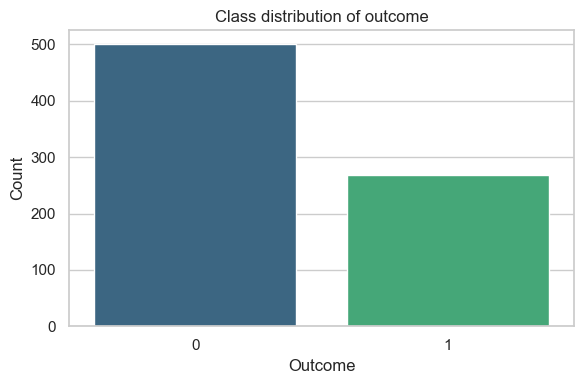

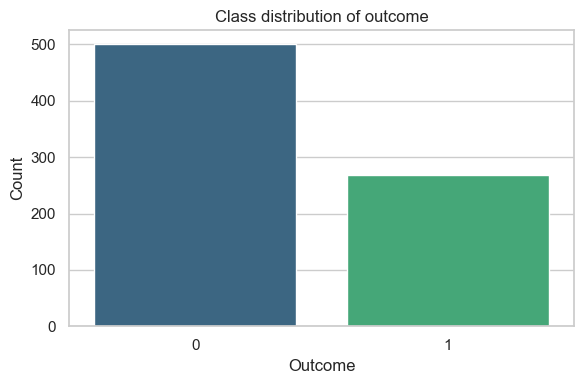

In [8]:
fig_class_dist, ax_class_dist = plt.subplots(figsize=(6, 4))
sns.barplot(
    x=class_distribution.index.astype(str),
    y=class_distribution['count'].values,
    ax=ax_class_dist,
    palette='viridis',
    hue=class_distribution.index.astype(str),
    legend=False,
)
ax_class_dist.set_title('Class distribution of outcome')
ax_class_dist.set_xlabel('Outcome')
ax_class_dist.set_ylabel('Count')
plt.tight_layout()
fig_class_dist


In [9]:
missing_report = pd.DataFrame(
    {
        'nan_count': df.isna().sum(),
        'nan_rate_pct': (100 * df.isna().mean()).round(2),
        'zero_count': (df == 0).sum(),
        'zero_rate_pct': (100 * (df == 0).mean()).round(2),
    }
)
duplicate_count = int(df.duplicated().sum())
duplicates_preview = df[df.duplicated()].head(10)
zero_focus_report = (
    missing_report.loc[zero_as_missing_columns + ['pregnancies', 'outcome']]
    .sort_values('zero_rate_pct', ascending=False)
    .copy()
)

df_masked = df.copy()
df_masked[zero_as_missing_columns] = df_masked[zero_as_missing_columns].replace(0, np.nan)

print('Duplicate rows:', duplicate_count)


Duplicate rows: 0


In [10]:
display(Markdown('## 3) Data Quality Checks'))
missing_report


## 3) Data Quality Checks

,nan_count,nan_rate_pct,zero_count,zero_rate_pct
pregnancies,0,0.0,111,14.45
glucose,0,0.0,5,0.65
blood_pressure,0,0.0,35,4.56
skin_thickness,0,0.0,227,29.56
insulin,0,0.0,374,48.70
bmi,0,0.0,11,1.43
diabetes_pedigree_function,0,0.0,0,0.00
age,0,0.0,0,0.00
outcome,0,0.0,500,65.10


In [11]:
display(Markdown('### Duplicate rows preview (nếu có)'))
duplicates_preview


### Duplicate rows preview (nếu có)

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome


In [12]:
zero_focus_report


,nan_count,nan_rate_pct,zero_count,zero_rate_pct
outcome,0,0.0,500,65.10
insulin,0,0.0,374,48.70
skin_thickness,0,0.0,227,29.56
pregnancies,0,0.0,111,14.45
blood_pressure,0,0.0,35,4.56
bmi,0,0.0,11,1.43
glucose,0,0.0,5,0.65


## 4) Phân tích chuyên sâu theo thuộc tính (tổng hợp từ nhóm)

### 4.1 Age - tương quan và quan hệ với glucose

,age
age,1.000000
pregnancies,0.544341
glucose,0.263514
blood_pressure,0.239528
outcome,0.238356
bmi,0.036242
diabetes_pedigree_function,0.033561
insulin,-0.042163
skin_thickness,-0.113970


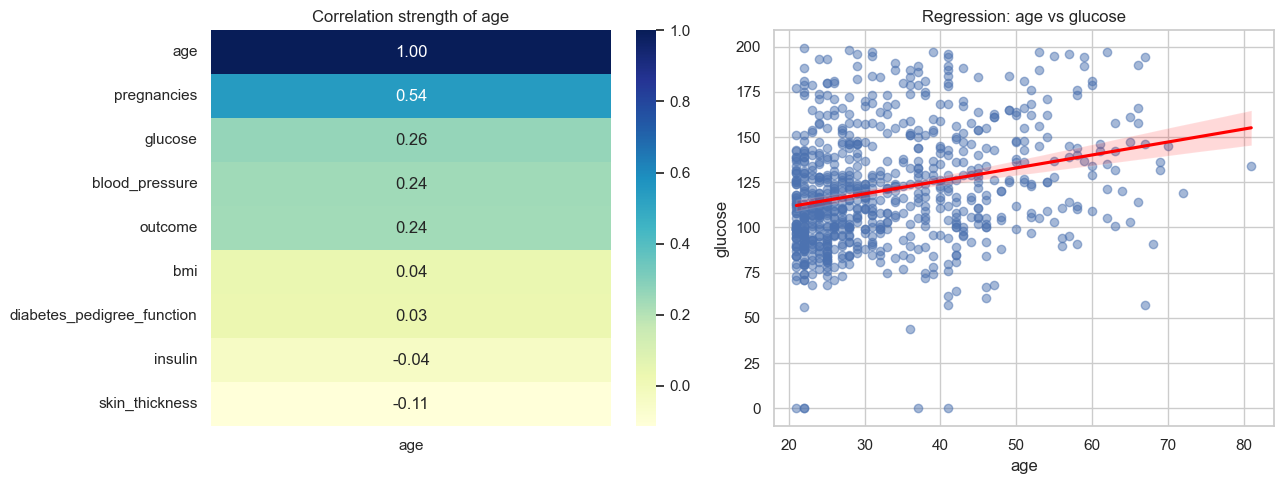

In [13]:
display(Markdown("## 4) Phân tích chuyên sâu theo thuộc tính (tổng hợp từ nhóm)"))

age_corr = df.corr(numeric_only=True)[["age"]].sort_values(by="age", ascending=False)
display(Markdown("### 4.1 Age - tương quan và quan hệ với glucose"))
display(age_corr)

fig_age, axes_age = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(age_corr, annot=True, cmap="YlGnBu", fmt=".2f", cbar=True, ax=axes_age[0])
axes_age[0].set_title("Correlation strength of age")

sns.regplot(data=df, x="age", y="glucose", scatter_kws={"alpha": 0.5}, line_kws={"color": "red"}, ax=axes_age[1])
axes_age[1].set_title("Regression: age vs glucose")
plt.tight_layout()
plt.show()


### 4.2 Diabetes Pedigree Function (DPF) - phân phối và mức độ rủi ro

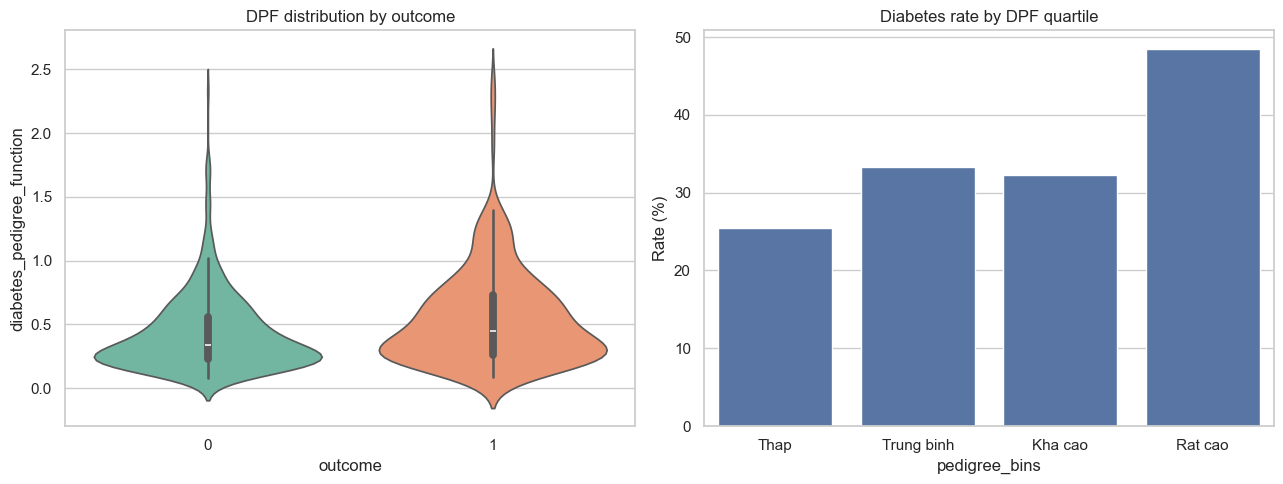

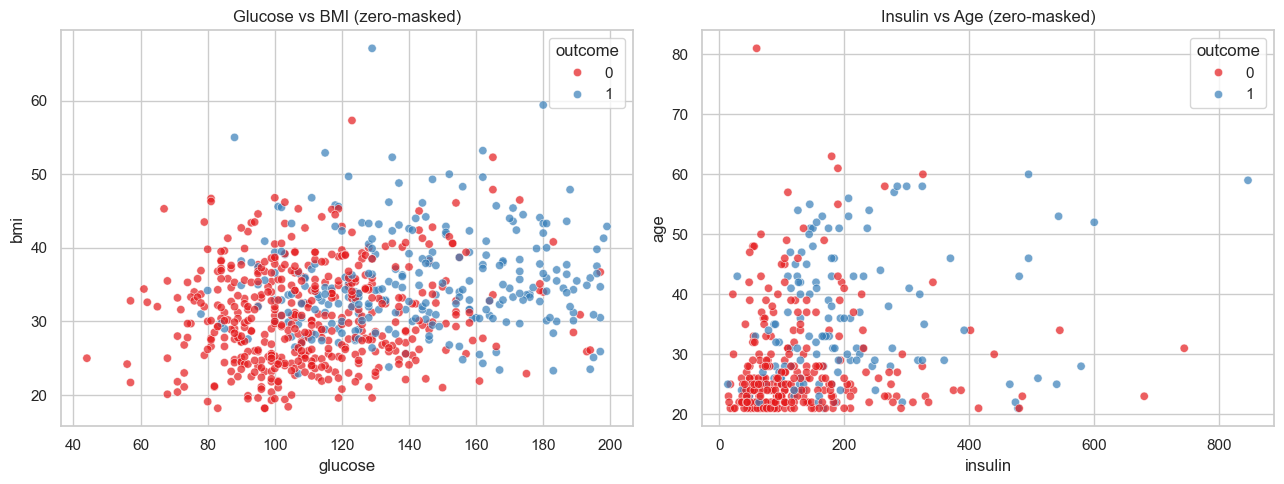

In [14]:
display(Markdown("### 4.2 Diabetes Pedigree Function (DPF) - phân phối và mức độ rủi ro"))

fig_dpf, axes_dpf = plt.subplots(1, 2, figsize=(13, 5))
sns.violinplot(data=df, x="outcome", y="diabetes_pedigree_function", palette="Set2", hue="outcome", legend=False, ax=axes_dpf[0])
axes_dpf[0].set_title("DPF distribution by outcome")

pedigree_df = df.copy()
pedigree_df["pedigree_bins"] = pd.qcut(
    pedigree_df["diabetes_pedigree_function"],
    q=4,
    labels=["Thap", "Trung binh", "Kha cao", "Rat cao"],
)
pedigree_risk = pedigree_df.groupby("pedigree_bins", observed=False)["outcome"].mean().mul(100).round(2)
sns.barplot(x=pedigree_risk.index, y=pedigree_risk.values, ax=axes_dpf[1], color="#4C72B0")
axes_dpf[1].set_title("Diabetes rate by DPF quartile")
axes_dpf[1].set_ylabel("Rate (%)")
plt.tight_layout()
plt.show()

fig_focus, axes_focus = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df_masked, x="glucose", y="bmi", hue="outcome", alpha=0.7, palette="Set1", ax=axes_focus[0])
axes_focus[0].set_title("Glucose vs BMI (zero-masked)")

sns.scatterplot(data=df_masked, x="insulin", y="age", hue="outcome", alpha=0.7, palette="Set1", ax=axes_focus[1])
axes_focus[1].set_title("Insulin vs Age (zero-masked)")
plt.tight_layout()
plt.show()


In [15]:
display(Markdown('## 4) Descriptive Statistics'))

display(df[feature_columns].describe().T)

grouped_stats = df.groupby('outcome')[feature_columns].agg(['mean', 'median', 'std']).round(3)
grouped_stats


## 4) Descriptive Statistics

,count,mean,std,min,25%,50%,75%,max
pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
blood_pressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
skin_thickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
bmi,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
diabetes_pedigree_function,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00


pregnancies                glucose                blood_pressure  \
               mean median    std     mean median     std           mean   
outcome                                                                    
0             3.298    2.0  3.017  109.980  107.0  26.141         68.184   
1             4.866    4.0  3.741  141.257  140.0  31.940         70.825   

                       skin_thickness  ...  insulin     bmi                \
        median     std           mean  ...      std    mean median    std   
outcome                                ...                                  
0         70.0  18.063         19.664  ...   98.865  30.304  30.05  7.690   
1         74.0  21.492         22.164  ...  138.689  35.143  34.25  7.263   

        diabetes_pedigree_function                   age                 
                              mean median    std    mean median     std  
outcome                                                                  
0                             0.43  0.336  0.299  31.190   27.0  11.668  
1                             0.55  0.449  0.372  37.067   36.0  10.968  

[2 rows x 24 columns]

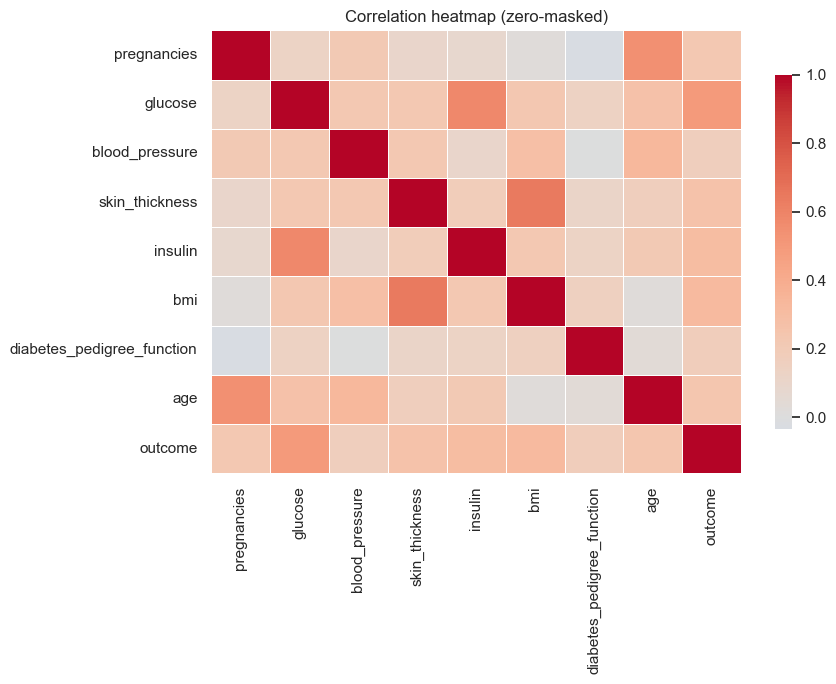

,corr_with_outcome
outcome,1.000000
glucose,0.494650
bmi,0.313680
insulin,0.303454
skin_thickness,0.259491
age,0.238356
pregnancies,0.221898
diabetes_pedigree_function,0.173844
blood_pressure,0.170589


In [16]:
corr_source = df_masked.copy()
corr_matrix = corr_source.corr(numeric_only=True)

fig_corr, ax_corr = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.4,
    cbar_kws={"shrink": 0.8},
    ax=ax_corr,
)
ax_corr.set_title("Correlation heatmap (zero-masked)")
plt.tight_layout()
plt.show()

corr_matrix["outcome"].sort_values(ascending=False).to_frame(name="corr_with_outcome")


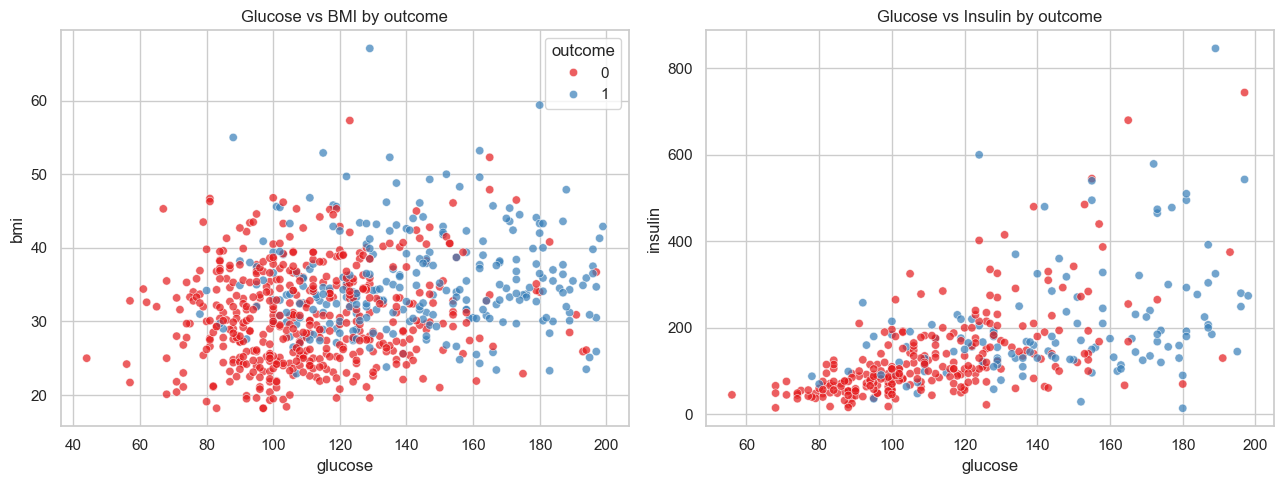

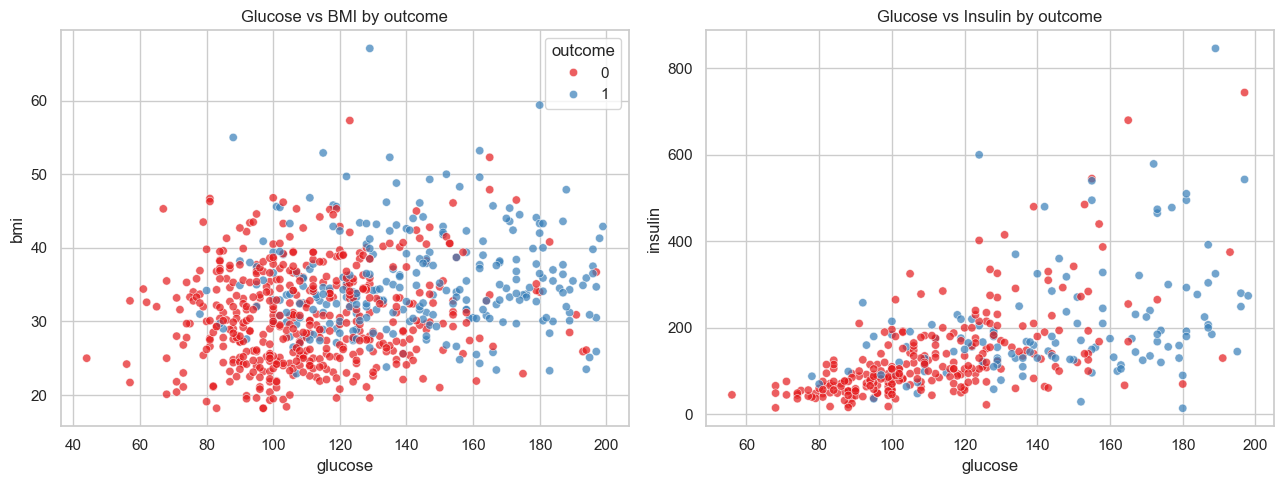

In [17]:
fig_scatter, axes_scatter = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=corr_source, x='glucose', y='bmi', hue='outcome', alpha=0.7, ax=axes_scatter[0], palette='Set1')
axes_scatter[0].set_title('Glucose vs BMI by outcome')

sns.scatterplot(data=corr_source, x='glucose', y='insulin', hue='outcome', alpha=0.7, ax=axes_scatter[1], palette='Set1', legend=False)
axes_scatter[1].set_title('Glucose vs Insulin by outcome')

plt.tight_layout()
fig_scatter


In [18]:
display(Markdown("## 6) Chuẩn bị dữ liệu và chiến lược đánh giá"))

display(
    Markdown(
        """
### 6.1. Lý do thiết kế tiền xử lý

- Các biến `glucose`, `blood_pressure`, `skin_thickness`, `insulin`, `bmi` có giá trị `0` không hợp lý về sinh lý trong nhiều bối cảnh lâm sàng, do đó được xem như missing ẩn.
- Với dữ liệu Pima, notebook **không loại bỏ outlier cứng** để tránh mất mẫu trên tập nhỏ; thay vào đó dùng các imputer và scaler để giảm tác động nhiễu trong huấn luyện.
- Các thuật toán dựa trên khoảng cách/gradient nhạy với chênh lệch thang đo, vì vậy cần so sánh chuẩn hóa `StandardScaler` và `MinMaxScaler`.
- Bài toán có khả năng bị ảnh hưởng bởi mất cân bằng lớp ở mức vừa phải; do đó cần theo dõi đồng thời `ROC-AUC`, `F1`, `precision`, `recall` thay vì chỉ `accuracy`.

### 6.2. Chiến lược đánh giá công bằng

- Chia dữ liệu theo `train/val/test = 60/20/20` với `stratify` để giữ tỷ lệ lớp dương ổn định giữa các tập.
- Mọi cấu hình (imputer + scaler + model) dùng cùng một split và cùng seed để so sánh công bằng.
- Chọn cấu hình theo hiệu năng tổng hợp trên validation và kiểm tra khả năng tổng quát hóa ở test.
"""
    )
)

X = df[feature_columns].copy()
y = df["outcome"].astype(int)

X[zero_as_missing_columns] = X[zero_as_missing_columns].replace(0, np.nan)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_state,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=random_state,
    stratify=y_train_val,
)

split_df = pd.DataFrame(
    {
        "subset": ["train", "val", "test"],
        "n_samples": [len(y_train), len(y_val), len(y_test)],
        "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    }
)
split_df["positive_rate"] = split_df["positive_rate"].round(4)
split_df


## 6) Chuẩn bị dữ liệu và chiến lược đánh giá


### 6.1. Lý do thiết kế tiền xử lý

- Các biến `glucose`, `blood_pressure`, `skin_thickness`, `insulin`, `bmi` có giá trị `0` không hợp lý về sinh lý trong nhiều bối cảnh lâm sàng, do đó được xem như missing ẩn.
- Với dữ liệu Pima, notebook **không loại bỏ outlier cứng** để tránh mất mẫu trên tập nhỏ; thay vào đó dùng các imputer và scaler để giảm tác động nhiễu trong huấn luyện.
- Các thuật toán dựa trên khoảng cách/gradient nhạy với chênh lệch thang đo, vì vậy cần so sánh chuẩn hóa `StandardScaler` và `MinMaxScaler`.
- Bài toán có khả năng bị ảnh hưởng bởi mất cân bằng lớp ở mức vừa phải; do đó cần theo dõi đồng thời `ROC-AUC`, `F1`, `precision`, `recall` thay vì chỉ `accuracy`.

### 6.2. Chiến lược đánh giá công bằng

- Chia dữ liệu theo `train/val/test = 60/20/20` với `stratify` để giữ tỷ lệ lớp dương ổn định giữa các tập.
- Mọi cấu hình (imputer + scaler + model) dùng cùng một split và cùng seed để so sánh công bằng.
- Chọn cấu hình theo hiệu năng tổng hợp trên validation và kiểm tra khả năng tổng quát hóa ở test.


,subset,n_samples,positive_rate
0,train,460,0.3478
1,val,154,0.3506
2,test,154,0.3506


In [19]:
display(Markdown("## 7) So sánh nhiều chiến lược imputation + scaling + baseline model"))

def build_model(model_name: str):
    if model_name == "logistic":
        return LogisticRegression(max_iter=5000, random_state=random_state)
    if model_name == "random_forest":
        return RandomForestClassifier(n_estimators=300, random_state=random_state)
    raise ValueError(f"Unsupported model: {model_name}")


def evaluate_strategy(imputer_name: str, scaler_name: str, model_name: str):
    if imputer_name == "median":
        imputer = SimpleImputer(strategy="median")
    elif imputer_name == "knn":
        imputer = KNNImputer(n_neighbors=5)
    elif imputer_name == "iterative":
        imputer = IterativeImputer(random_state=random_state, max_iter=10)
    else:
        raise ValueError(f"Unsupported imputer: {imputer_name}")

    if scaler_name == "standard":
        scaler = StandardScaler()
    elif scaler_name == "minmax":
        scaler = MinMaxScaler()
    else:
        raise ValueError(f"Unsupported scaler: {scaler_name}")

    model = build_model(model_name)
    pipe = Pipeline(
        steps=[
            ("imputer", imputer),
            ("scaler", scaler),
            ("model", model),
        ]
    )

    pipe.fit(X_train, y_train)

    y_val_pred = pipe.predict(X_val)
    y_val_prob = pipe.predict_proba(X_val)[:, 1]

    y_test_pred = pipe.predict(X_test)
    y_test_prob = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        "imputer": imputer_name,
        "scaler": scaler_name,
        "model": model_name,
        "val_accuracy": accuracy_score(y_val, y_val_pred),
        "val_f1": f1_score(y_val, y_val_pred),
        "val_roc_auc": roc_auc_score(y_val, y_val_prob),
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "test_precision": precision_score(y_test, y_test_pred),
        "test_recall": recall_score(y_test, y_test_pred),
        "test_f1": f1_score(y_test, y_test_pred),
        "test_roc_auc": roc_auc_score(y_test, y_test_prob),
    }

    artifacts = {
        "pipe": pipe,
        "y_test_pred": y_test_pred,
        "y_test_prob": y_test_prob,
        "y_val_pred": y_val_pred,
        "y_val_prob": y_val_prob,
    }

    return metrics, artifacts


strategies = []
strategy_artifacts = {}
for imputer_name in ["median", "knn", "iterative"]:
    for scaler_name in ["standard", "minmax"]:
        for model_name in ["logistic", "random_forest"]:
            metrics, artifacts = evaluate_strategy(imputer_name, scaler_name, model_name)
            key = f"{imputer_name}|{scaler_name}|{model_name}"
            strategy_artifacts[key] = artifacts
            strategies.append(metrics)

comparison_df = pd.DataFrame(strategies).sort_values(by=["test_roc_auc", "test_f1"], ascending=False)
comparison_df.round(4)


## 7) So sánh nhiều chiến lược imputation + scaling + baseline model

,imputer,scaler,model,val_accuracy,val_f1,val_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
7,knn,minmax,random_forest,0.7727,0.6465,0.8700,0.7403,0.6458,0.5741,0.6078,0.8170
5,knn,standard,random_forest,0.7727,0.6465,0.8690,0.7403,0.6458,0.5741,0.6078,0.8168
0,median,standard,logistic,0.7792,0.6531,0.8498,0.7078,0.6000,0.5000,0.5455,0.8167
11,iterative,minmax,random_forest,0.7922,0.6800,0.8572,0.7273,0.6250,0.5556,0.5882,0.8156
4,knn,standard,logistic,0.7922,0.6667,0.8526,0.7143,0.6136,0.5000,0.5510,0.8154
9,iterative,standard,random_forest,0.7857,0.6733,0.8556,0.7273,0.6250,0.5556,0.5882,0.8153
3,median,minmax,random_forest,0.7857,0.6733,0.8596,0.7338,0.6383,0.5556,0.5941,0.8149
8,iterative,standard,logistic,0.7857,0.6598,0.8476,0.7143,0.6190,0.4815,0.5417,0.8148
1,median,standard,random_forest,0.7792,0.6667,0.8604,0.7338,0.6383,0.5556,0.5941,0.8136
6,knn,minmax,logistic,0.8117,0.6882,0.8730,0.7208,0.6341,0.4815,0.5474,0.8117


## 8) Phân tích kết quả mô hình và sai số

Phần dưới đây tập trung vào chất lượng mô hình theo góc nhìn báo cáo: xếp hạng cấu hình, confusion matrix của cấu hình tốt nhất, ROC của các cấu hình top, và thảo luận trade-off giữa `precision`/`recall`.

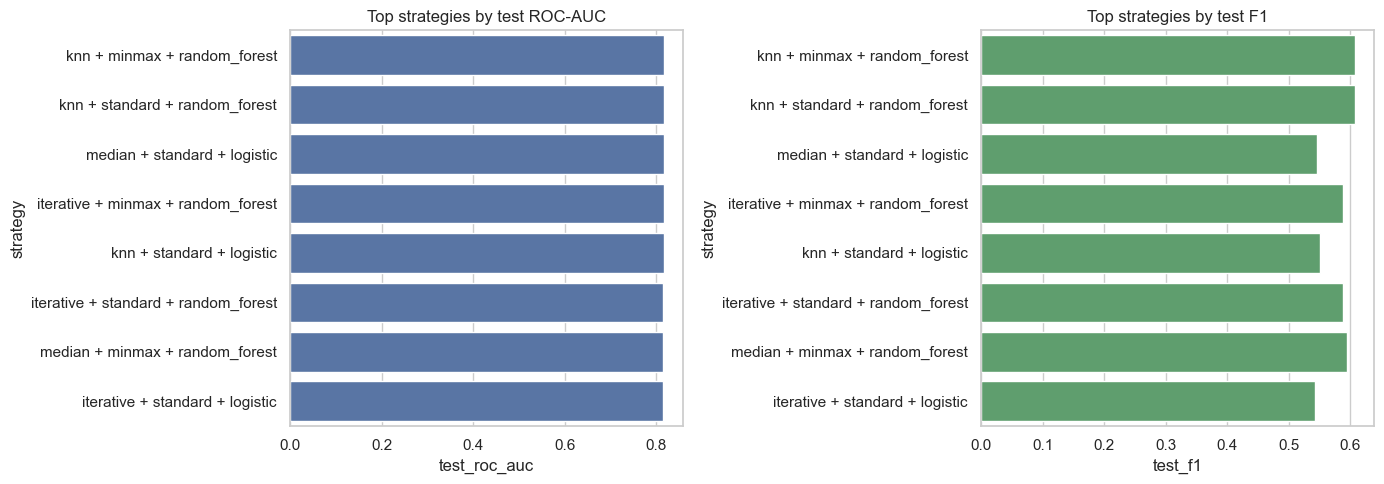

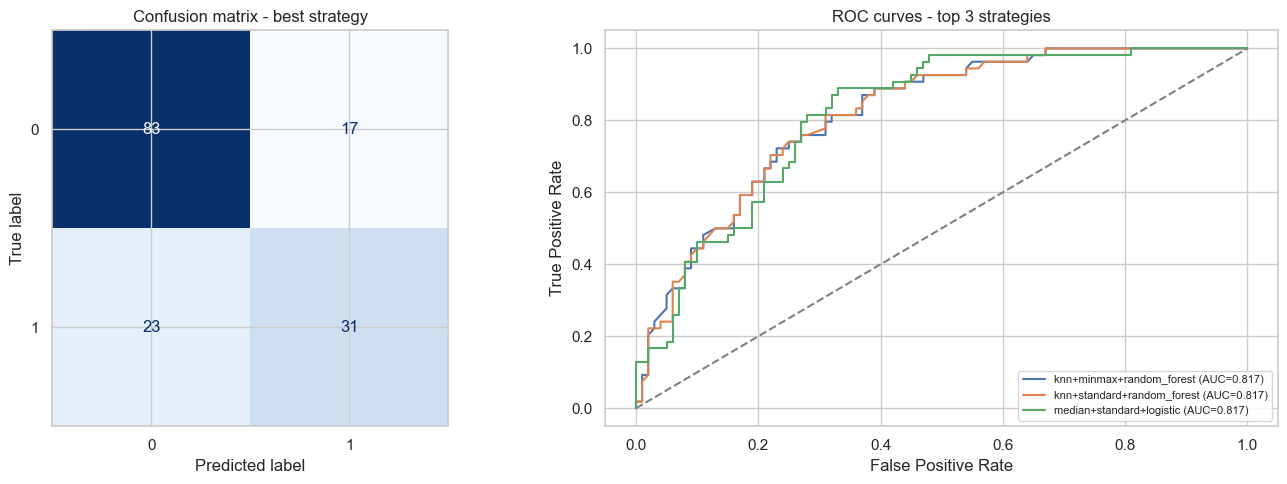

,threshold,precision,recall,f1
0,0.30,0.5789,0.8148,0.6769
1,0.35,0.5970,0.7407,0.6612
2,0.40,0.6167,0.6852,0.6491
3,0.45,0.6296,0.6296,0.6296
4,0.50,0.6458,0.5741,0.6078
5,0.55,0.6429,0.5000,0.5625
6,0.60,0.6944,0.4630,0.5556
7,0.65,0.7188,0.4259,0.5349
8,0.70,0.7500,0.3333,0.4615


In [20]:
top_view = comparison_df.copy()
top_view["strategy"] = top_view["imputer"] + " + " + top_view["scaler"] + " + " + top_view["model"]

fig_cmp, axes_cmp = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=top_view.head(8), y="strategy", x="test_roc_auc", ax=axes_cmp[0], color="#4C72B0")
axes_cmp[0].set_title("Top strategies by test ROC-AUC")
axes_cmp[0].set_xlabel("test_roc_auc")

sns.barplot(data=top_view.head(8), y="strategy", x="test_f1", ax=axes_cmp[1], color="#55A868")
axes_cmp[1].set_title("Top strategies by test F1")
axes_cmp[1].set_xlabel("test_f1")

plt.tight_layout()
plt.show()

best_row = comparison_df.iloc[0]
best_key = f"{best_row['imputer']}|{best_row['scaler']}|{best_row['model']}"
best_artifacts = strategy_artifacts[best_key]

fig_eval, axes_eval = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_artifacts["y_test_pred"], ax=axes_eval[0], cmap="Blues", colorbar=False)
axes_eval[0].set_title("Confusion matrix - best strategy")

for _, row in comparison_df.head(3).iterrows():
    key = f"{row['imputer']}|{row['scaler']}|{row['model']}"
    probs = strategy_artifacts[key]["y_test_prob"]
    fpr, tpr, _ = roc_curve(y_test, probs)
    label = f"{row['imputer']}+{row['scaler']}+{row['model']} (AUC={row['test_roc_auc']:.3f})"
    axes_eval[1].plot(fpr, tpr, label=label)

axes_eval[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes_eval[1].set_title("ROC curves - top 3 strategies")
axes_eval[1].set_xlabel("False Positive Rate")
axes_eval[1].set_ylabel("True Positive Rate")
axes_eval[1].legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

thresholds = np.arange(0.30, 0.75, 0.05)
threshold_rows = []
for thr in thresholds:
    pred_thr = (best_artifacts["y_test_prob"] >= thr).astype(int)
    threshold_rows.append(
        {
            "threshold": round(float(thr), 2),
            "precision": precision_score(y_test, pred_thr),
            "recall": recall_score(y_test, pred_thr),
            "f1": f1_score(y_test, pred_thr),
        }
    )

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.round(4)

In [21]:
gap_auc = best_row["val_roc_auc"] - best_row["test_roc_auc"]
if abs(gap_auc) <= 0.03:
    overfit_comment = "Chênh lệch val/test nhỏ, dấu hiệu tổng quát hóa tương đối ổn định."
elif gap_auc > 0.03:
    overfit_comment = "Val tốt hơn test đáng kể, có rủi ro overfitting nhẹ đến trung bình."
else:
    overfit_comment = "Test tốt hơn val, có thể do nhiễu chia tập hoặc variance của dữ liệu nhỏ."

best_tradeoff = threshold_df.iloc[(threshold_df["f1"]).idxmax()]

final_md = f"""
### 8.1. Khuyến nghị cấu hình preprocessing

- Cấu hình tốt nhất theo `test_roc_auc`: **{best_row['imputer']} + {best_row['scaler']} + {best_row['model']}**.
- `val_roc_auc`: **{best_row['val_roc_auc']:.4f}**
- `test_roc_auc`: **{best_row['test_roc_auc']:.4f}**
- `test_f1`: **{best_row['test_f1']:.4f}**
- `test_precision`: **{best_row['test_precision']:.4f}**
- `test_recall`: **{best_row['test_recall']:.4f}**

### 8.2. Nhận định trade-off precision/recall

- Threshold mặc định 0.50 chưa chắc tối ưu cho mục tiêu phát hiện ca dương tính.
- Theo bảng threshold, điểm cân bằng tốt nhất theo F1 nằm quanh **{best_tradeoff['threshold']:.2f}**.
- Ở threshold này: `precision={best_tradeoff['precision']:.4f}`, `recall={best_tradeoff['recall']:.4f}`, `f1={best_tradeoff['f1']:.4f}`.

### 8.3. Dấu hiệu overfitting/underfitting (sơ bộ)

- `val_roc_auc - test_roc_auc = {gap_auc:.4f}`.
- {overfit_comment}

### Checklist yêu cầu Lab 03 (Bài 2)

- [x] Định nghĩa vấn đề phân lớp và xác định input/output.
- [x] Tải dữ liệu và mô tả thuộc tính từ file `.names`.
- [x] Phân tích dữ liệu: mô tả thống kê, phân bố lớp, tương quan, trực quan đơn biến/đa biến.
- [x] Làm sạch dữ liệu: kiểm tra trùng lặp, xử lý missing ẩn dưới giá trị 0.
- [x] Chuẩn hóa và chia dữ liệu train/val/test có stratify.
- [x] So sánh nhiều chiến lược tiền xử lý và baseline để chọn cấu hình đề xuất.
- [x] Phân tích kết quả mô hình theo confusion matrix, ROC và threshold trade-off.
"""

display(Markdown(final_md))


### 8.1. Khuyến nghị cấu hình preprocessing

- Cấu hình tốt nhất theo `test_roc_auc`: **knn + minmax + random_forest**.
- `val_roc_auc`: **0.8700**
- `test_roc_auc`: **0.8170**
- `test_f1`: **0.6078**
- `test_precision`: **0.6458**
- `test_recall`: **0.5741**

### 8.2. Nhận định trade-off precision/recall

- Threshold mặc định 0.50 chưa chắc tối ưu cho mục tiêu phát hiện ca dương tính.
- Theo bảng threshold, điểm cân bằng tốt nhất theo F1 nằm quanh **0.30**.
- Ở threshold này: `precision=0.5789`, `recall=0.8148`, `f1=0.6769`.

### 8.3. Dấu hiệu overfitting/underfitting (sơ bộ)

- `val_roc_auc - test_roc_auc = 0.0530`.
- Val tốt hơn test đáng kể, có rủi ro overfitting nhẹ đến trung bình.

### Checklist yêu cầu Lab 03 (Bài 2)

- [x] Định nghĩa vấn đề phân lớp và xác định input/output.
- [x] Tải dữ liệu và mô tả thuộc tính từ file `.names`.
- [x] Phân tích dữ liệu: mô tả thống kê, phân bố lớp, tương quan, trực quan đơn biến/đa biến.
- [x] Làm sạch dữ liệu: kiểm tra trùng lặp, xử lý missing ẩn dưới giá trị 0.
- [x] Chuẩn hóa và chia dữ liệu train/val/test có stratify.
- [x] So sánh nhiều chiến lược tiền xử lý và baseline để chọn cấu hình đề xuất.
- [x] Phân tích kết quả mô hình theo confusion matrix, ROC và threshold trade-off.


In [22]:
limitations_md = """
## 9) Hạn chế nghiên cứu

1. **Giới hạn dữ liệu**: bộ Pima có quy mô nhỏ (768 mẫu) và chỉ gồm các biến lâm sàng cơ bản, chưa có thông tin điều trị, bệnh sử chi tiết hoặc yếu tố hành vi.
2. **Giả định missing**: quy ước `0` là missing ở một số biến sinh lý hợp lý về mặt miền tri thức, nhưng vẫn có thể tạo sai lệch nếu tồn tại trường hợp đo thực sự bằng 0.
3. **Thiết kế thực nghiệm**: so sánh hiện dùng một lần chia train/val/test; chưa dùng cross-validation lặp lại nên độ ổn định còn phụ thuộc seed.
4. **Tối ưu mô hình**: chưa thực hiện hyperparameter tuning có hệ thống (Grid/Random/Bayesian search), chưa đánh giá calibration xác suất.
5. **Khả năng khái quát hóa**: kết quả chủ yếu phản ánh dữ liệu Pima, chưa kiểm định external validity trên tập dân số khác.

## 10) Hướng phát triển và kiến nghị

1. Áp dụng **Stratified K-Fold CV** để đánh giá ổn định và giảm phụ thuộc vào một lần chia dữ liệu.
2. Bổ sung **hyperparameter tuning** cho Logistic Regression và Random Forest để cải thiện hiệu năng và tính công bằng khi so sánh.
3. Mở rộng phân tích với **calibration curve** và tối ưu threshold theo mục tiêu nghiệp vụ (ưu tiên recall hoặc precision).
4. Thử thêm mô hình boosting (XGBoost/LightGBM) và phương pháp cân bằng lớp nếu cần.
5. Đóng gói pipeline suy luận và tạo báo cáo tự động để dễ tái lập khi cập nhật dữ liệu.
"""

display(Markdown(limitations_md))


## 9) Hạn chế nghiên cứu

1. **Giới hạn dữ liệu**: bộ Pima có quy mô nhỏ (768 mẫu) và chỉ gồm các biến lâm sàng cơ bản, chưa có thông tin điều trị, bệnh sử chi tiết hoặc yếu tố hành vi.
2. **Giả định missing**: quy ước `0` là missing ở một số biến sinh lý hợp lý về mặt miền tri thức, nhưng vẫn có thể tạo sai lệch nếu tồn tại trường hợp đo thực sự bằng 0.
3. **Thiết kế thực nghiệm**: so sánh hiện dùng một lần chia train/val/test; chưa dùng cross-validation lặp lại nên độ ổn định còn phụ thuộc seed.
4. **Tối ưu mô hình**: chưa thực hiện hyperparameter tuning có hệ thống (Grid/Random/Bayesian search), chưa đánh giá calibration xác suất.
5. **Khả năng khái quát hóa**: kết quả chủ yếu phản ánh dữ liệu Pima, chưa kiểm định external validity trên tập dân số khác.

## 10) Hướng phát triển và kiến nghị

1. Áp dụng **Stratified K-Fold CV** để đánh giá ổn định và giảm phụ thuộc vào một lần chia dữ liệu.
2. Bổ sung **hyperparameter tuning** cho Logistic Regression và Random Forest để cải thiện hiệu năng và tính công bằng khi so sánh.
3. Mở rộng phân tích với **calibration curve** và tối ưu threshold theo mục tiêu nghiệp vụ (ưu tiên recall hoặc precision).
4. Thử thêm mô hình boosting (XGBoost/LightGBM) và phương pháp cân bằng lớp nếu cần.
5. Đóng gói pipeline suy luận và tạo báo cáo tự động để dễ tái lập khi cập nhật dữ liệu.
